In [1]:
# TODO write this as normal .py script
import matplotlib.pyplot as plt
import xarray as xr
import pym

from imagematerials.factory import ModelFactory, Sector
from imagematerials.read_mym import read_mym_df
from imagematerials.rest_of.util import sum_inflows_for_all_sectors, sand_gravel_crushed_rock_equivalent

import sys
import os
sys.path.append(os.path.abspath(".."))


from pathlib import Path


In [2]:
model_runs = {scenario_name: ModelFactory.load_pkl(f"../../../examples/model_results/{scenario_name}_model.pkl") for scenario_name in ["SSP2_M_CP", "SSP2_M_CP_with_re"]}
baseline = model_runs.get('SSP2_M_CP')
resource_eff = model_runs.get('SSP2_M_CP_with_re')

start_implementation_year = 2025

In [3]:
# Read gompertz calues from standard run 
gompertz_original = xr.open_dataarray('../../../data/raw/rest-of/gompertz_values/coefs_gompertz.nc')

In [4]:
gdp_cap = read_mym_df('../../../data/raw/image/SSP2_M_CP/Socioeconomic/gdp_pc.scn')
population = read_mym_df('../../../data/raw/image/SSP2_M_CP/Socioeconomic/pop.scn')
gdp_cap.index.name = "time"
population.index.name = "time"

from imagematerials.constants import IMAGE_REGIONS

import xarray as xr
gdp_cap_xr = xr.DataArray(
    gdp_cap.loc[:, :26].values,
    dims=["time", "Region"],
    coords={"time": gdp_cap.index, "Region": IMAGE_REGIONS}
 )

population_xr = xr.DataArray(
   population.loc[:, :26].values,
   dims=["time", "Region"],
   coords={"time": population.index, "Region": IMAGE_REGIONS}
)

gdp = gdp_cap_xr*population_xr

# rename dims to fit capitalized Time

In [5]:
from imagematerials.rest_of.util import sum_inflows_for_all_sectors

# sum all inflows for both runs
list_sum_sectors_all = ["buildings", "vehicles", "elc_gen", "elc_grid_lines", "elc_grid_add", "elc_stor_phs", "elc_stor_other"]

total_inflow_base = sum_inflows_for_all_sectors(baseline, 'inflow_materials', list_sum_sectors_all)
total_inflow_eff = sum_inflows_for_all_sectors(resource_eff, 'inflow_materials', list_sum_sectors_all)


In [6]:
# Calculate material intensities

import numpy as np

from imagematerials.rest_of.util import calculate_cement_equivalent

for material in gompertz_original.material.values:
    if material in ['clay', 'limestone']: 
        # for limestone and clay take sand_gravel_crushed_rock efficiency gains as a proxy for these materials
        inflow = sand_gravel_crushed_rock_equivalent(total_inflow_base, include_rest_bool = False).sum('Type')
        inflow_eff = sand_gravel_crushed_rock_equivalent(total_inflow_eff, include_rest_bool = False).sum('Type')
        inflow = inflow.assign_coords(material='sand')
        inflow_eff = inflow_eff.assign_coords(material='sand')

        # overwrite material name
        inflow = inflow.assign_coords(material=material)
        inflow_eff = inflow_eff.assign_coords(material=material)
    elif material == 'sand':
        # replace with sand_gravel_crushed_rock_equivalent
        inflow = sand_gravel_crushed_rock_equivalent(total_inflow_base, include_rest_bool = False).sum('Type')
        inflow_eff = sand_gravel_crushed_rock_equivalent(total_inflow_eff, include_rest_bool = False).sum('Type')
        inflow = inflow.assign_coords(material='sand')
        inflow_eff = inflow_eff.assign_coords(material='sand')
    elif material == 'cement':
        inflow = calculate_cement_equivalent(total_inflow_base, include_rest_of = False).sum('Type')
        inflow_eff = calculate_cement_equivalent(total_inflow_eff, include_rest_of = False).sum('Type')
    else:
        inflow = total_inflow_base.sel(material=material).sum('Type')
        inflow_eff = total_inflow_eff.sel(material=material).sum('Type')

    # Material intensities per GDP
    material_intensity_base = inflow / gdp
    material_intensity_eff = inflow_eff / gdp

    # calculate the percentual resource efficiency
    resource_eff_procentual = (material_intensity_base - material_intensity_eff) / material_intensity_base * 100
    # calculate the reduction per year
    resource_eff_procentual_year = resource_eff_procentual.diff(dim='time').fillna(0)

    # save all materials from material_intensity_base in a new joint xarray under the material dimension
    if material == 'aluminium':
        # start to save in new xarray
        all_materials_resource_eff_procentual = resource_eff_procentual
        all_materials_resource_eff_per_year = resource_eff_procentual_year
    else:
        all_materials_resource_eff_procentual = xr.concat([all_materials_resource_eff_procentual, resource_eff_procentual], dim='material')
        all_materials_resource_eff_per_year = xr.concat([all_materials_resource_eff_per_year, resource_eff_procentual_year], dim='material')

# add clay and limestone with nans


summed cement and cement in concrete.
summed cement and cement in concrete.
summed cement and cement in concrete.
summed sand in cement and sand in glass.
summed cement and cement in concrete.
summed sand in cement and sand in glass.
summed cement and cement in concrete.
summed sand in cement and sand in glass.
summed cement and cement in concrete.
summed sand in cement and sand in glass.
summed cement and cement in concrete.
summed sand in cement and sand in glass.
summed cement and cement in concrete.
summed sand in cement and sand in glass.


C:\Users\Arp00003\AppData\Local\Temp\ipykernel_22048\399407328.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


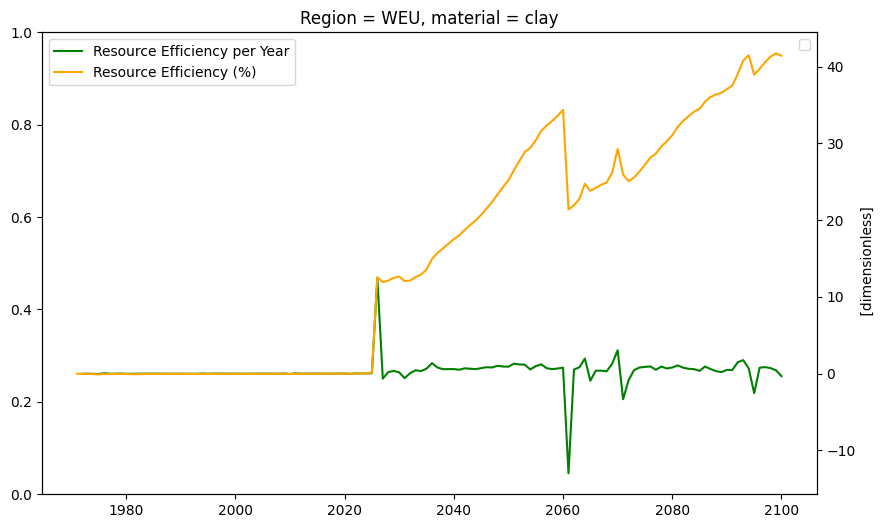

In [7]:
material = 'clay'
region = 'WEU'

fig, ax = plt.subplots(figsize=(10,6))

# inflow_base = total_inflow_base.loc[1980:].sel(material=material, Region=region).sum('Type').plot(label ='Base Inflow', color = 'black', ax=ax)
# inflow_eff = total_inflow_eff.loc[1980:].sel(material=material, Region=region).sum('Type').plot(label ='Eff Inflow', color = 'blue', ax=ax)
plt.legend()
# secondary axis on the other side
ax2 = ax.twinx()
all_materials_resource_eff_per_year.sel(material=material, Region = region).plot(label = 'Resource Efficiency per Year', color = 'green', ax=ax2)
all_materials_resource_eff_procentual.sel(material = material, Region = region).plot(label = 'Resource Efficiency (%)', color = 'orange', ax=ax2)

plt.legend()

In [8]:
# manipuate gompertz coefs
a0 = gompertz_original.sel(coef='a')
# per-year multiplier (choose sign correctly: reductions -> 1 - r_frac)
per_year_multiplier = 1 - (all_materials_resource_eff_procentual / 100.0) 

In [9]:
# rename coordinate per_year_multiplier from time to Time
per_year_multiplier = per_year_multiplier.rename({'time':'Time'})


In [10]:
a0_expanded = a0.copy()
a_t = (a0_expanded * per_year_multiplier)
gompertz_eff = gompertz_original.copy()

# apply a 10-year rolling mean to smoothen & extend to edges
a_t_rolling_5 = a_t.rolling(Time=5, center=False, min_periods=1).mean() 
a_t_rolling_10 = a_t.rolling(Time=10, center=False, min_periods=1).mean()
a_t_rolling_15 = a_t.rolling(Time=15, center=False, min_periods=1).mean()
a_t_rolling_20 = a_t.rolling(Time=20, center=False, min_periods=1).mean() # take this one
# a_t_rolling_true = a_t.rolling(Time=10, center=True).mean()
# a_t_rolling = a_t.rolling(Time=10, center=True).mean()

gompertz_eff.loc[dict(coef='a')] = a_t_rolling_20

c:\Users\Arp00003\AppData\Local\miniconda3\envs\materials_dev\Lib\site-packages\xarray\core\indexing.py:1689: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  array[key] = value


In [11]:
# make sure that gompertz_eff and gompertz_original have the same values until 2019
gompertz_eff = gompertz_eff.where(gompertz_eff.Time >= start_implementation_year-1, other=gompertz_original)

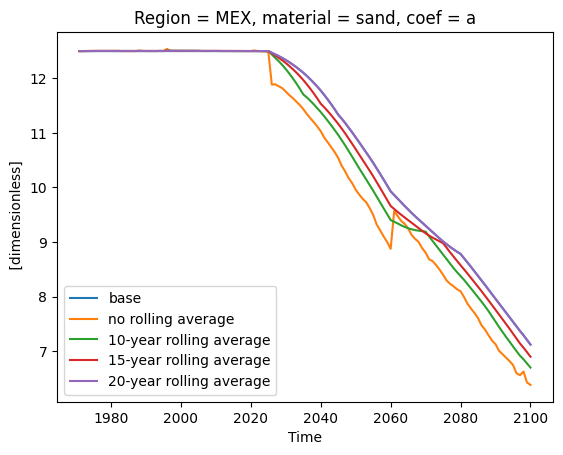

In [12]:
material_sel = 'sand'
region_sel = 'MEX'

gompertz_eff.sel(coef='a').sel(material = material_sel, Region = region_sel).plot(label = 'base')
a_t.sel(material=material_sel, Region=region_sel).plot(label = 'no rolling average')
a_t_rolling_10.sel(material=material_sel, Region=region_sel).plot(label = '10-year rolling average')
a_t_rolling_15.sel(material=material_sel, Region=region_sel).plot(label = '15-year rolling average')
a_t_rolling_20.sel(material=material_sel, Region=region_sel).plot(label = '20-year rolling average')

plt.legend()
# save new gompertz coefs
gompertz_eff.to_netcdf('../../../data/raw/rest-of/gompertz_values/coefs_gompertz_eff.nc')


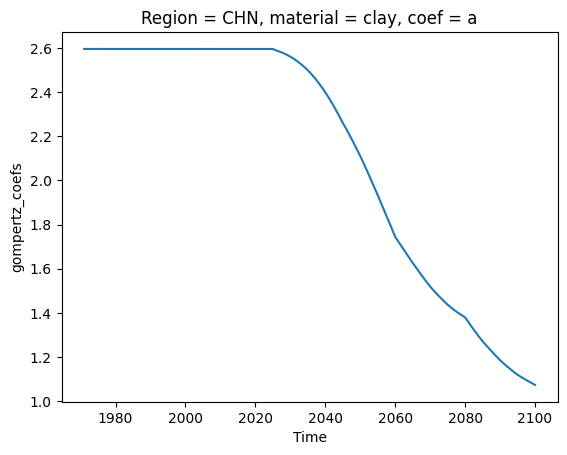

In [13]:
gompertz_eff.sel(material = 'clay').sel(coef='a').sel(Region = 'CHN').plot()